In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# bibliotecas do scikit-learn para redução de dimensionalidade
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)




In [3]:
# carregando os dados das amostras da Etapa 3.5
caminho_atributos = '../dados/dados_processados/atributos_amostrados.csv'
caminho_rotulos = '../dados/dados_processados/rotulos_amostrados.csv'
caminho_codificador = '../modelos/codificador_rotulos_amostrado.pkl'

print(" Carregando dados amostrados...")
X = pd.read_csv(caminho_atributos)
y = pd.read_csv(caminho_rotulos).iloc[:, 0]  
codificador = joblib.load(caminho_codificador)

print(f"\n Dados carregados")
print(f"  Atributos: {X.shape}")
print(f"  Rótulos:   {y.shape}")
print(f"  Classes:       {list(codificador.classes_)}")

print(f"\n Distribuição das classes:")
for codigo, nome in enumerate(codificador.classes_):
    qtd = (y == codigo).sum()
    print(f"   {nome:15s} (código {codigo}): {qtd:,} registros")


 Carregando dados amostrados...

 Dados carregados
  Atributos: (10000, 78)
  Rótulos:   (10000,)
  Classes:       ['BENIGN', 'DDoS', 'DoS Hulk', 'PortScan']

 Distribuição das classes:
   BENIGN          (código 0): 2,500 registros
   DDoS            (código 1): 2,500 registros
   DoS Hulk        (código 2): 2,500 registros
   PortScan        (código 3): 2,500 registros


In [4]:
# antes de aplicar PCA/LDA, vamos mostrar o cenário atual
n_atributos_original = X.shape[1]
n_amostras = X.shape[0]
n_classes = len(codificador.classes_)

print("Cenário atual dos dados:")
print("=" * 50)
print(f"   Número de amostras:        {n_amostras:,}")
print(f"   Número de atributos:       {n_atributos_original}")
print(f"   Número de classes:         {n_classes}")
print("=" * 50)

print(f"\nLimites técnicos:")
print(f"   PCA pode reduzir até:      {min(n_amostras, n_atributos_original)} componentes")
print(f"   LDA pode reduzir até:      {n_classes - 1} componentes (limite de k-1)")


Cenário atual dos dados:
   Número de amostras:        10,000
   Número de atributos:       78
   Número de classes:         4

Limites técnicos:
   PCA pode reduzir até:      78 componentes
   LDA pode reduzir até:      3 componentes (limite de k-1)


In [6]:
# aplicando PCA sem limitar componentes inicialmente

print("Aplicando PCA para todos os componentes")
pca_exploratorio = PCA(random_state=1)
pca_exploratorio.fit(X)

# variância explicada por cada componente
variancia_explicada = pca_exploratorio.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

print(f"PCA aplicado")
print(f" Total de componentes possíveis: {len(variancia_explicada)}")

# encontrando quantos componentes precisamos para diferentes limiares
limiares = [0.80, 0.90, 0.95, 0.99]
print(f"\nQuantidade de componentes e suas variâncias:")
print("=" * 50)
for limiar in limiares:
    n_comp = np.argmax(variancia_acumulada >= limiar) + 1
    print(f"   {limiar*100:.0f}% da variância: {n_comp} componentes")
print("=" * 50)


Aplicando PCA para todos os componentes
PCA aplicado
 Total de componentes possíveis: 78

Quantidade de componentes e suas variâncias:
   80% da variância: 5 componentes
   90% da variância: 10 componentes
   95% da variância: 15 componentes
   99% da variância: 25 componentes


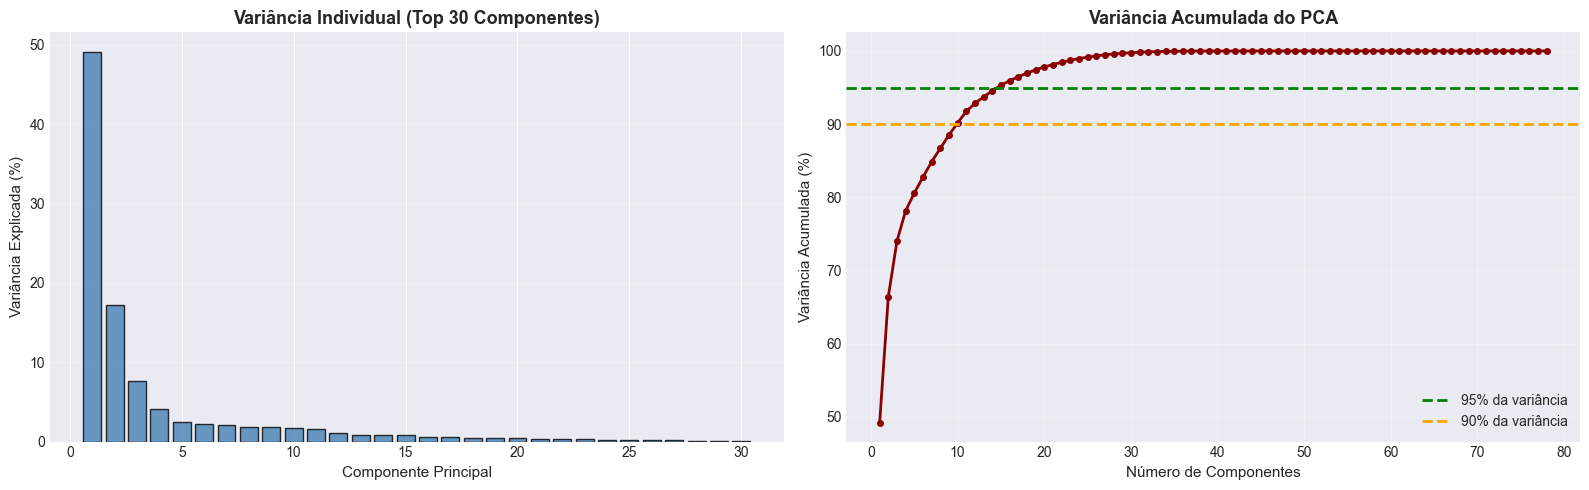

In [7]:
# no passo anterior foi possivel perceber que mesmo com apenas 25 componentes ja possuimos quase 100% da variancia
# então poderemos reduzir muito a quantidade dos atributos


# aqui dois gráficos vão ficar lado a lado para análise da variância
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# gráfico 1: variância individual de cada componente (top 30)
n_plot = min(30, len(variancia_explicada))
axes[0].bar(range(1, n_plot + 1), variancia_explicada[:n_plot] * 100, 
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Componente Principal', fontsize=11)
axes[0].set_ylabel('Variância Explicada (%)', fontsize=11)
axes[0].set_title(f'Variância Individual (Top {n_plot} Componentes)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# gráfico 2: variância acumulada
axes[1].plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada * 100, 
             marker='o', markersize=4, color='darkred', linewidth=2)
axes[1].axhline(y=95, color='green', linestyle='--', label='95% da variância', linewidth=2)
axes[1].axhline(y=90, color='orange', linestyle='--', label='90% da variância', linewidth=2)
axes[1].set_xlabel('Número de Componentes', fontsize=11)
axes[1].set_ylabel('Variância Acumulada (%)', fontsize=11)
axes[1].set_title('Variância Acumulada do PCA', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
# aplicando PCA mantendo 95% da variância
print("Aplicando PCA com 95% da variância\n")

pca = PCA(n_components=0.95, random_state=1)
X_pca = pca.fit_transform(X)

n_componentes_pca = pca.n_components_

print(f"PCA aplicado")
print(f" Atributos originais:       {n_atributos_original}")
print(f" Componentes do PCA:        {n_componentes_pca}")
print(f" Redução:                   {n_atributos_original - n_componentes_pca} dimensões ({(1 - n_componentes_pca/n_atributos_original)*100:.1f}%)")
print(f" Variância preservada:      {sum(pca.explained_variance_ratio_)*100:.2f}%")

# convertendo para dataframe com nomes de colunas significativas
colunas_pca = [f'PC{i+1}' for i in range(n_componentes_pca)] # pc para remeter a pca
X_pca_df = pd.DataFrame(X_pca, columns=colunas_pca)

print(f"\n Primeiras linhas dos dados transformados (PCA):")
X_pca_df.head()


Aplicando PCA com 95% da variância

PCA aplicado
 Atributos originais:       78
 Componentes do PCA:        15
 Redução:                   63 dimensões (80.8%)
 Variância preservada:      95.32%

 Primeiras linhas dos dados transformados (PCA):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,-4.792546,-0.212098,0.451895,0.017264,1.276715,0.205145,-0.602757,0.083356,-0.573021,-0.348058,-0.178464,0.180480,-0.272344,-0.001741,0.671684
1,-4.257191,-1.125135,-1.015202,0.014076,-1.383037,-0.295493,0.765549,0.312919,-0.277279,-0.212176,-0.722938,0.302501,0.120123,0.089289,-0.989745
2,4.426122,8.281754,1.399511,-0.258595,-0.253788,0.005868,-0.076021,-0.324258,0.143029,-0.112951,-0.071047,-0.799742,-0.022615,0.060568,-0.870279
3,1.060095,5.105217,1.315270,-0.218623,0.304204,0.288245,-0.741563,-0.502919,-0.223084,0.067771,0.359342,-1.314314,0.410489,-0.226734,-0.332738
4,4.925069,-0.020966,4.220890,0.619813,-1.308920,-0.421729,1.069812,-0.318917,-0.796320,0.084871,0.506133,-0.736267,0.724212,2.230803,-0.120577


In [10]:
# aplicando LDA (limitado a n_classes - 1 = 3 componentes)
print("Aplicando LDA \n")

n_componentes_lda = n_classes - 1  # = 3

lda = LDA(n_components=n_componentes_lda)
X_lda = lda.fit_transform(X, y)

print(f"LDA aplicado")
print(f" Atributos originais:       {n_atributos_original}")
print(f" Componentes do LDA:        {n_componentes_lda}")
print(f" Redução:                   {n_atributos_original - n_componentes_lda} dimensões ({(1 - n_componentes_lda/n_atributos_original)*100:.1f}%)")
print(f" Variância entre classes:   {sum(lda.explained_variance_ratio_)*100:.2f}%")

# Convertendo para DataFrame
colunas_lda = [f'LD{i+1}' for i in range(n_componentes_lda)] # ld para remeter a lda
X_lda_df = pd.DataFrame(X_lda, columns=colunas_lda)

print(f"\nPrimeiras linhas dos dados transformados (LDA):")
X_lda_df.head()


Aplicando LDA 

LDA aplicado
 Atributos originais:       78
 Componentes do LDA:        3
 Redução:                   75 dimensões (96.2%)
 Variância entre classes:   100.00%

Primeiras linhas dos dados transformados (LDA):


,LD1,LD2,LD3
0,-5.867234,1.616568,0.785387
1,2.762277,-1.919288,1.513808
2,3.372469,-1.993707,3.038976
3,2.420386,-0.814343,2.259527
4,7.110000,1.906520,-1.923882


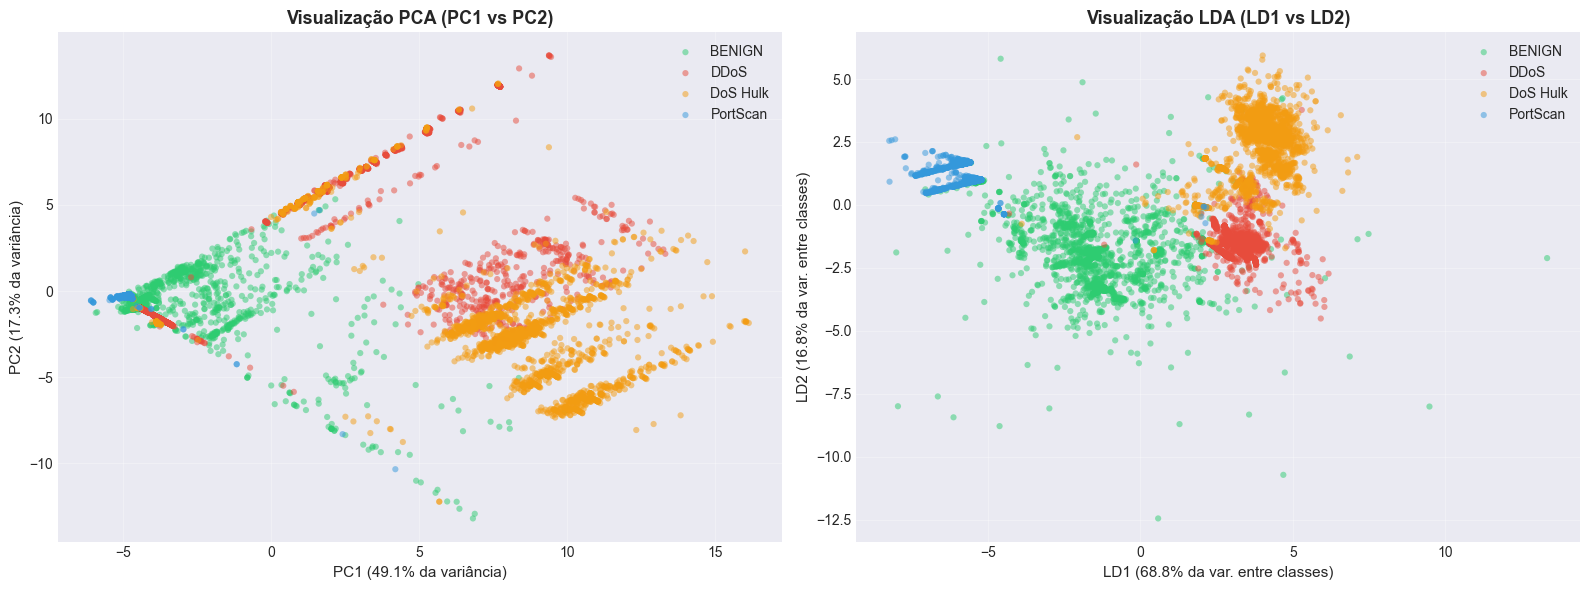

In [11]:
# visualizando os dois primeiros componentes (atributos) do PCA após sua aplicação
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cores = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
nomes_classes = list(codificador.classes_)

# gráfico PCA (PC1 vs PC2)
for codigo, nome, cor in zip(range(n_classes), nomes_classes, cores):
    mask = y == codigo
    axes[0].scatter(X_pca_df.loc[mask, 'PC1'], X_pca_df.loc[mask, 'PC2'],
                    c=cor, label=nome, alpha=0.5, s=20, edgecolors='none')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)', fontsize=11)
axes[0].set_title('Visualização PCA (PC1 vs PC2)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='best')
axes[0].grid(alpha=0.3)

# visualizando os dois primeiros componentes (atributos) do LDA após sua aplicação

# gráfico LDA (LD1 vs LD2)
for codigo, nome, cor in zip(range(n_classes), nomes_classes, cores):
    mask = y == codigo
    axes[1].scatter(X_lda_df.loc[mask, 'LD1'], X_lda_df.loc[mask, 'LD2'],
                    c=cor, label=nome, alpha=0.5, s=20, edgecolors='none')

axes[1].set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% da var. entre classes)', fontsize=11)
axes[1].set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% da var. entre classes)', fontsize=11)
axes[1].set_title('Visualização LDA (LD1 vs LD2)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# definindo caminhos de saída
pasta_dados = '../dados/dados_processados/'
pasta_modelos = '../modelos/'

# caminhos dos dados transformados (CSV)
caminho_X_pca = os.path.join(pasta_dados, 'atributos_pca.csv')
caminho_X_lda = os.path.join(pasta_dados, 'atributos_lda.csv')

# caminhos dos modelos treinados (PKL)
caminho_pca_modelo = os.path.join(pasta_modelos, 'modelo_pca.pkl')
caminho_lda_modelo = os.path.join(pasta_modelos, 'modelo_lda.pkl')

print("Salvando arquivos\n")

# salvando arquivos CSV
X_pca_df.to_csv(caminho_X_pca, index=False)
print(f"  Dados PCA:     {caminho_X_pca} ({X_pca_df.shape})")

X_lda_df.to_csv(caminho_X_lda, index=False)
print(f"  Dados LDA:     {caminho_X_lda} ({X_lda_df.shape})")

# salvando os modelos
joblib.dump(pca, caminho_pca_modelo)
print(f"  Modelo PCA:    {caminho_pca_modelo}")

joblib.dump(lda, caminho_lda_modelo)
print(f"  Modelo LDA:    {caminho_lda_modelo}")



Salvando arquivos

  Dados PCA:     ../dados/dados_processados/atributos_pca.csv ((10000, 15))
  Dados LDA:     ../dados/dados_processados/atributos_lda.csv ((10000, 3))
  Modelo PCA:    ../modelos/modelo_pca.pkl
  Modelo LDA:    ../modelos/modelo_lda.pkl


In [15]:
# resumo comparativo das três versões dos dados
print("           RESUMO COMPARATIVO ")
print("=" * 60)
print(f"{'Versão':<15} {'Dimensões':<15} {'Redução':<15} {'Tipo':<15}")
print("=" * 60)
print(f"{'Original':<15} {f'{n_atributos_original} atributos':<15} {'—':<15} {'—':<15}")
print(f"{'PCA (95%)':<15} {f'{n_componentes_pca} componentes':<15} {f'{(1-n_componentes_pca/n_atributos_original)*100:.1f}%':<15} {'Não-supervisionado':<15}")
print(f"{'LDA':<15} {f'{n_componentes_lda} componentes':<15} {f'{(1-n_componentes_lda/n_atributos_original)*100:.1f}%':<15} {'Supervisionado':<15}")
print("=" * 60)




           RESUMO COMPARATIVO 
Versão          Dimensões       Redução         Tipo           
Original        78 atributos    —               —              
PCA (95%)       15 componentes  80.8%           Não-supervisionado
LDA             3 componentes   96.2%           Supervisionado 
